Muestra de las nuevas características integradas al dataset limpio:


,num__promedio_notas,indice_eficiencia_academica,riesgo_sobrecarga,ratio_compromiso_asincrono
0,0.647268,2.907058,2.737521,0.028775
1,-1.567069,-1.400755,7.074313,-0.446071
2,1.669269,1.192978,2.315872,0.256256
3,0.000000,0.000000,5.923444,-0.520386
4,-0.204400,-0.246953,2.994279,0.161538


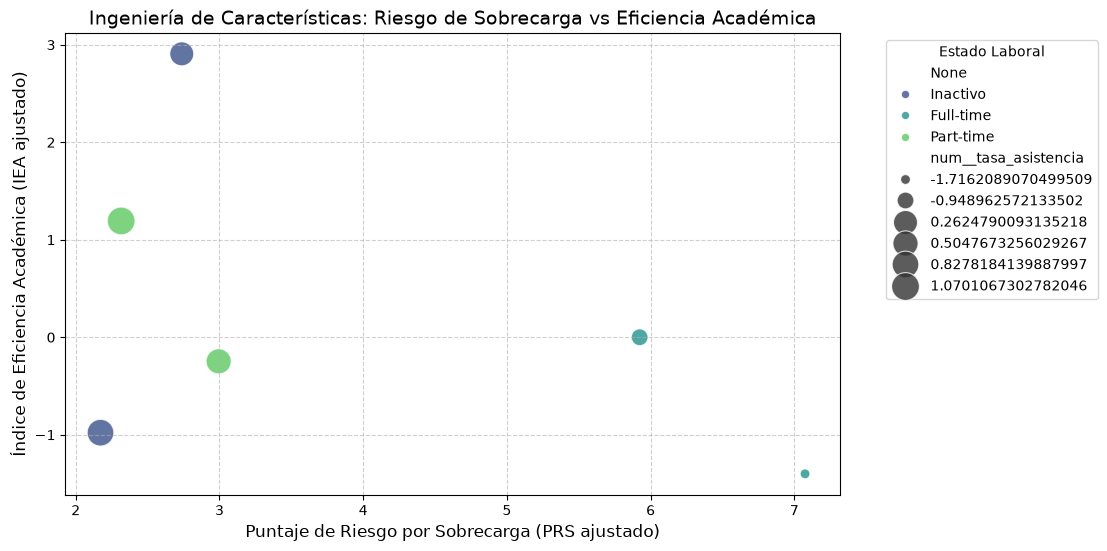

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df_limpio = pd.read_csv('../data/processed/estudiantes_limpios.csv')

engineer_features = lambda df: df.assign(
    indice_eficiencia_academica = df['num__promedio_notas'] / (np.abs(df['skewed__minutos_totales_lms']) + 0.1),

    riesgo_sobrecarga = (3.0 - df['num__tasa_asistencia']) * (
        (df.get('nominal__estado_laboral_Full-time', 0.0) * 1.5) +
        (df.get('nominal__estado_laboral_Part-time', 0.0) * 1.2) +
        (df.get('nominal__estado_laboral_Inactivo', 0.0) * 1.0)
    ),
    ratio_compromiso_asincrono = df['skewed__minutos_totales_lms'] / (df['num__tasa_asistencia'] + 4.0)
)

def plot_feature_engineering(df_engineered):
    plt.figure(figsize=(10, 6))

    estado_laboral_visual = df_engineered[['nominal__estado_laboral_Full-time', 'nominal__estado_laboral_Part-time', 'nominal__estado_laboral_Inactivo']].idxmax(axis=1).str.replace('nominal__estado_laboral_', '')
    
    sns.scatterplot(
        data=df_engineered, 
        x='riesgo_sobrecarga', 
        y='indice_eficiencia_academica', 
        hue=estado_laboral_visual,
        size='num__tasa_asistencia',
        sizes=(50, 400),
        palette='viridis',
        alpha=0.8
    )
    plt.title('Ingeniería de Características: Riesgo de Sobrecarga vs Eficiencia Académica', fontsize=14)
    plt.xlabel('Puntaje de Riesgo por Sobrecarga (PRS ajustado)', fontsize=12)
    plt.ylabel('Índice de Eficiencia Académica (IEA ajustado)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Estado Laboral', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    os.makedirs('../reports/figures', exist_ok=True)
    plt.savefig('../reports/figures/feature_engineering.png', dpi=300, bbox_inches='tight')
    plt.show()

df_features = engineer_features(df_limpio)

print("Muestra de las nuevas características integradas al dataset limpio:")
display(df_features[['num__promedio_notas', 'indice_eficiencia_academica', 'riesgo_sobrecarga', 'ratio_compromiso_asincrono']].head())

plot_feature_engineering(df_features)